In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import torch
import torch.nn as nn
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
import numpy as np

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath("../models"))

from dataset import load_data
from encoder import Encoder
from mamlnet import MAMLNet
from protonet import ProtoNet
from utils import deterministic, plot_accuracies_all_models, plot_tsnes_all_models
from maml_utils import evaluate_domains_maml
from protonet_utils import evaluate_domains_protonet

In [3]:
with open("../config/config.yaml", "r") as f:
    config = yaml.safe_load(f)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [6]:
experiment_parameters = config["compare_experiments"]
ks = experiment_parameters["ks"]
q = experiment_parameters["q_query"]
n_way = experiment_parameters["n_way"]
episodes = experiment_parameters["episodes"]

accuracies = {"Mnist": [], "Mnist-M": [], "Svhn": []}

data = "Mnist"
test_mnist_images, test_mnist_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Mnist_M"
test_mnist_m_images, test_mnist_m_labels = load_data("test", config[data]["dataset_output_dir"])

data = "Svhn"
test_svhn_images, test_svhn_labels = load_data("test", config[data]["dataset_output_dir"])

test_data = {"Mnist": (test_mnist_images, test_mnist_labels),
             "Mnist-M": (test_mnist_m_images, test_mnist_m_labels),
             "Svhn": (test_svhn_images, test_svhn_labels)}

## ProtoNet

In [ ]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["protonet"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]


encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protonet_model = ProtoNet(encoder)
protonet_model.load("../models/weights/protonet.pth", device)


accuracies_protonet = evaluate_domains_protonet(model=protonet_model,test_data=test_data, n_way=n_way,
                              ks=ks, q=q, episodes=episodes, device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_protonet['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_protonet['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_protonet['Svhn'][ks.index(k)]:.4f}")

In [ ]:
path = "../results/protonet_accuracies_ks.npy"
np.save(path, accuracies_protonet)

## Maml

In [ ]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["maml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
maml_model = MAMLNet(encoder, n_way=n_way, protomaml=False)
maml_model.load("../models/weights/maml.pth", device)

accuracies_maml = evaluate_domains_maml(model=maml_model,test_data=test_data, n_way=n_way, ks=ks, q=q,
                                        episodes=episodes, inner_updates=inner_updates, alpha=alpha,
                                        device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_maml['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_maml['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_maml['Svhn'][ks.index(k)]:.4f}")


In [ ]:
path = "../results/maml_accuracies_ks.npy"
np.save(path, accuracies_maml)

## ProtoMAML

In [ ]:
deterministic(config["xtra"]["seed"])

experiment_parameters = config["protomaml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protomaml_model = MAMLNet(encoder, n_way=n_way, protomaml=True)
protomaml_model.load("../models/weights/protomaml.pth", device)

accuracies_protomaml = evaluate_domains_maml(model=protomaml_model,test_data=test_data, n_way=n_way, ks=ks, q=q,
                                        episodes=episodes, inner_updates=inner_updates, alpha=alpha,
                                        device=device)

for k in ks:
    print(f"K={k} Accuracy: Mnist={accuracies_protomaml['Mnist'][ks.index(k)]:.4f}, "
          f"Mnist-M={accuracies_protomaml['Mnist-M'][ks.index(k)]:.4f}, "
          f"Svhn={accuracies_protomaml['Svhn'][ks.index(k)]:.4f}")

In [ ]:
path = "../results/protomaml_accuracies_ks.npy"
np.save(path, accuracies_protomaml)

## K vs Accuracy

In [ ]:
path = "../results/protonet_accuracies_ks.npy"
accuracies_protonet = np.load(path, allow_pickle=True).item()

path = "../results/maml_accuracies_ks.npy"
accuracies_maml = np.load(path, allow_pickle=True).item()

path = "../results/protomaml_accuracies_ks.npy"
accuracies_protomaml = np.load(path, allow_pickle=True).item()

In [ ]:
models_names = ["Protonet", "MAML", "ProtoMAML"]
accuracies_all_models = [accuracies_protonet, accuracies_maml, accuracies_protomaml]
plot_accuracies_all_models(ks, accuracies_all_models, models_names)


## TSNES

In [7]:
experiment_parameters = config["protonet"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]


encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protonet_model = ProtoNet(encoder)
protonet_model.load("../models/weights/protonet.pth", device)

In [8]:
experiment_parameters = config["maml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
maml_model = MAMLNet(encoder, n_way=n_way, protomaml=False)
maml_model.load("../models/weights/maml.pth", device)

In [9]:
experiment_parameters = config["protomaml"]
inner_updates = experiment_parameters["inner_updates"]
alpha = experiment_parameters["alpha"]

in_channels = experiment_parameters["in_channels"]
hidden_dim = experiment_parameters["hidden_dim"]
embedding_dim = experiment_parameters["embedding_dim"]

encoder = Encoder(in_channels=in_channels, hidden_dim=hidden_dim, embedding_dim=embedding_dim)
protomaml_model = MAMLNet(encoder, n_way=n_way, protomaml=True)
protomaml_model.load("../models/weights/protomaml.pth", device)

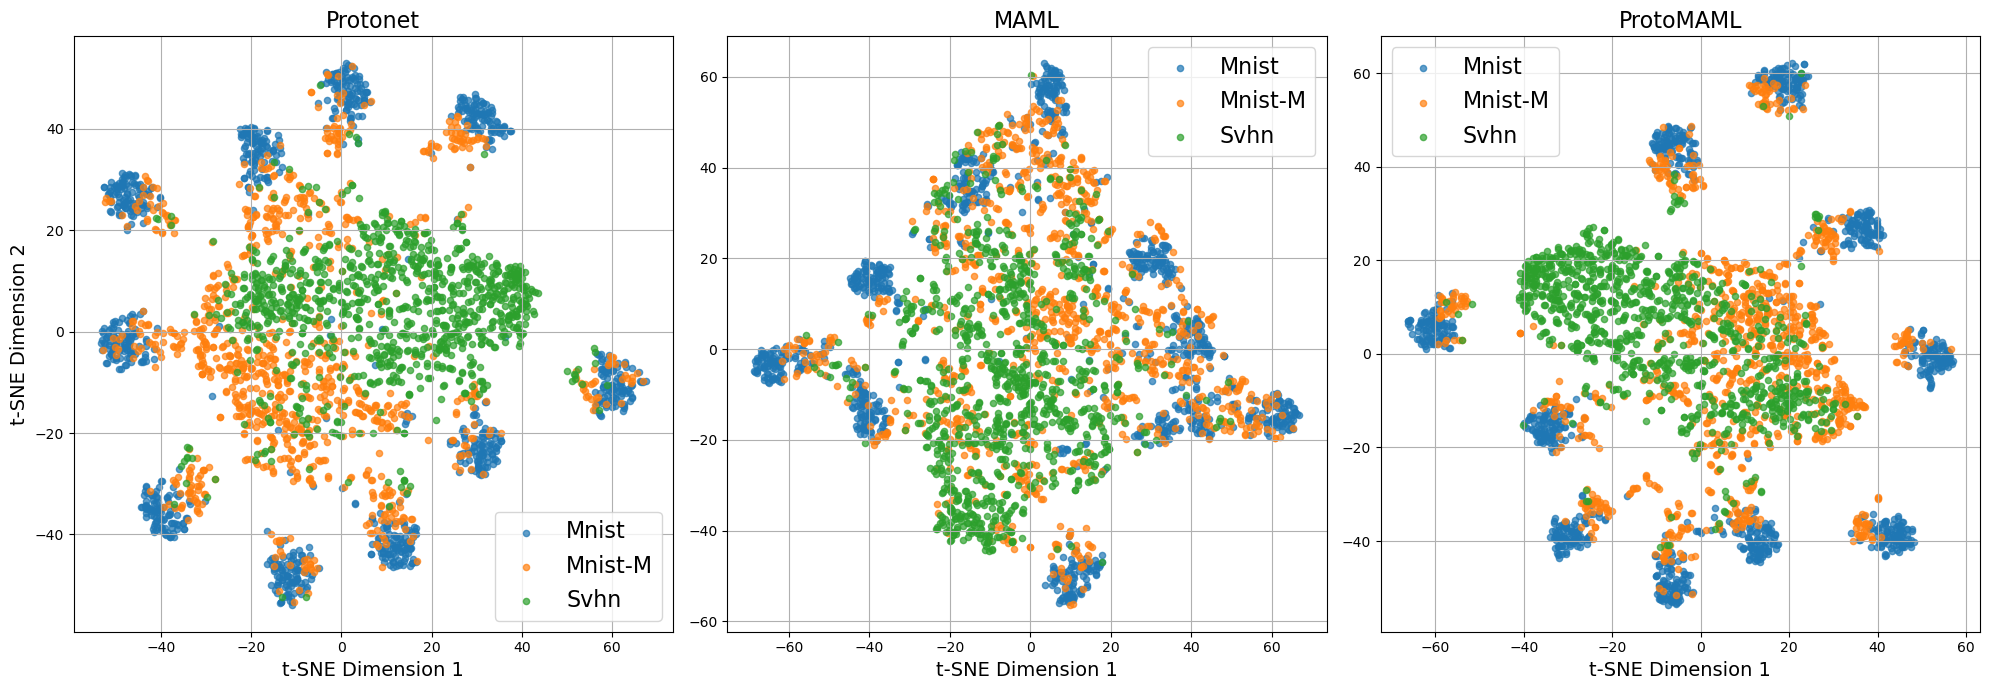

In [10]:
deterministic(config["xtra"]["seed"])
models = [protonet_model, maml_model, protomaml_model]
models_name = ["Protonet", "MAML", "ProtoMAML"]
samples_per_class = 100
plot_tsnes_all_models(models, models_name, test_data, samples_per_class, device, config["xtra"]["seed"])